In [ ]:
import SimpleITK as sitk
import numpy as np 
from skimage.segmentation import clear_border
from matplotlib.colors import ListedColormap

import matplotlib.pyplot as plt 
import cv2 as cv
from scipy.ndimage import (
    generate_binary_structure,
    binary_opening,
    binary_propagation,
    label,
    sum as nd_sum
)


img_sitk = sitk.ReadImage('3702_left_knee.nii') 
img_sitk

<SimpleITK.SimpleITK.Image; proxy of <Swig Object of type 'itk::simple::Image *' at 0x701f365b8d50> >

In [2]:
image = sitk.GetArrayFromImage(img_sitk) 
image.shape

(216, 512, 512)

In [3]:
axial_index = image.shape[0] // 2      # 216 -> 108
coronal_index = image.shape[1] // 2    # 512 -> 256
sagittal_index = image.shape[2] // 2   # 512 -> 256

### Segmentation Basics

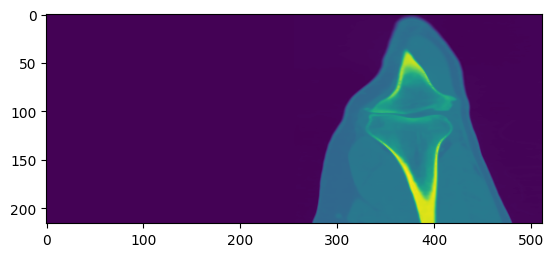

In [4]:
smoothed = sitk.CurvatureFlow(image1=img_sitk,
                               timeStep=0.225,
                               numberOfIterations=5)
plt.imshow(sitk.GetArrayFromImage(smoothed)[:, coronal_index, :])

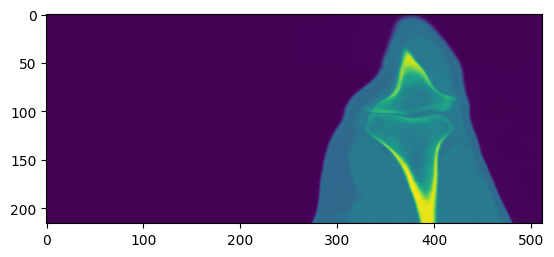

In [5]:
gaussian_blur = sitk.DiscreteGaussian(smoothed, variance=0.4)
gaussian_blur

plt.imshow(sitk.GetArrayFromImage(gaussian_blur)[:, coronal_index, :])

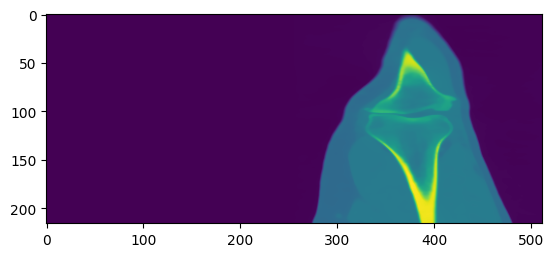

In [6]:
bilateral = sitk.Bilateral(gaussian_blur,
                           domainSigma=2.0,   # spatial extent
                           rangeSigma=50.0)
plt.imshow(sitk.GetArrayFromImage(bilateral)[:, coronal_index, :])

In [7]:
image_np = sitk.GetArrayFromImage(bilateral)
image_np.shape 

(216, 512, 512)

In [8]:
axial_slice = image_np[axial_index, :, :]       # shape: (512, 512)
coronal_slice = image_np[:, coronal_index, :]   # shape: (216, 512)
sagittal_slice = image_np[:, :, sagittal_index] # shape: (216, 512)

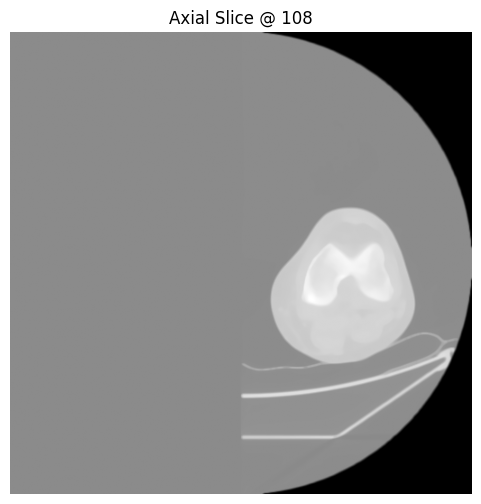

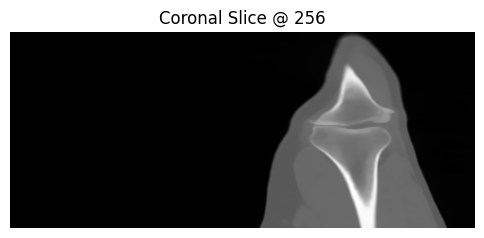

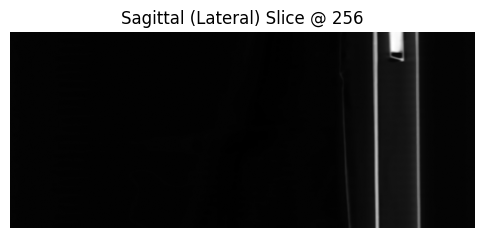

In [9]:
plt.figure(figsize=(6, 6))
plt.imshow(axial_slice, cmap='gray')
plt.title(f'Axial Slice @ {axial_index}')
plt.axis('off')
plt.show()

plt.figure(figsize=(6, 6))
plt.imshow(coronal_slice, cmap='gray')
plt.title(f'Coronal Slice @ {coronal_index}')
plt.axis('off')
plt.show()

plt.figure(figsize=(6, 6))
plt.imshow(sagittal_slice, cmap='gray')
plt.title(f'Sagittal (Lateral) Slice @ {sagittal_index}')
plt.axis('off')
plt.show()

(216, 512, 512) <class 'numpy.ndarray'>


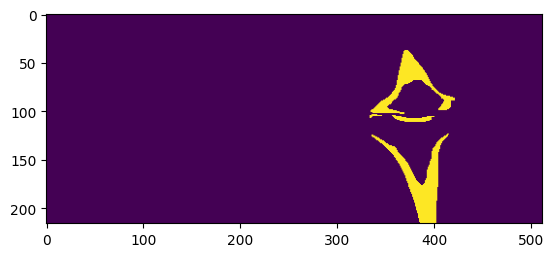

In [51]:
from skimage import filters, measure, morphology, segmentation, color, exposure
from scipy import ndimage as ndi

image = image_np

blurred = filters.gaussian(image, sigma=0.1)
print(blurred.shape, type(blurred))


threshold = 400
binary = image > threshold

plt.imshow(binary[:, coronal_index, :])

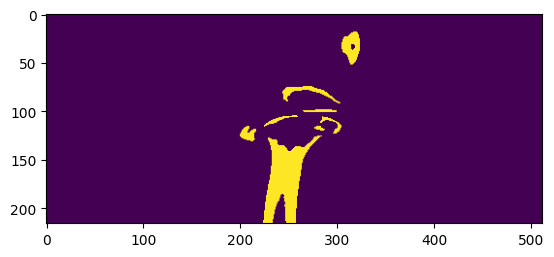

In [16]:
plt.imshow(binary[:, :, 400])

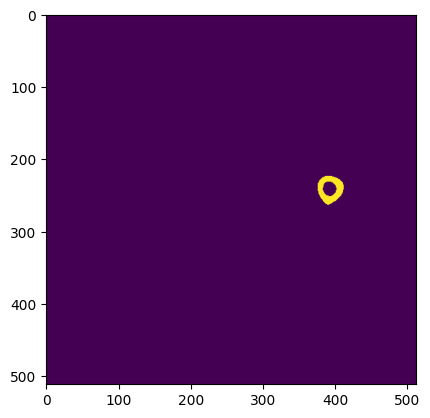

In [14]:
plt.imshow(binary[200, :, :])


In [25]:
binary = binary.astype(np.uint8)
binary.shape, binary.dtype, binary.min(), binary.max()

((216, 512, 512), dtype('uint8'), np.uint8(0), np.uint8(1))

In [23]:
# label connected components in 3d
cc_filter = sitk.ConnectedComponentImageFilter()
help(cc_filter)

Help on ConnectedComponentImageFilter in module SimpleITK.SimpleITK object:

class ConnectedComponentImageFilter(ImageFilter)
 |  Label the objects in a binary image.
 |
 |
 |  ConnectedComponentImageFilter labels the objects in a binary image (non-zero pixels are considered
 |  to be objects, zero-valued pixels are considered to be background).
 |  Each distinct object is assigned a unique label. The filter
 |  experiments with some improvements to the existing implementation, and
 |  is based on run length encoding along raster lines. If the output
 |  background value is set to zero (the default), the final object labels
 |  start with 1 and are consecutive. If the output background is set to a
 |  non-zero value (by calling the SetBackgroundValue() routine of the
 |  filter), the final labels start at 0, and remain consecutive except
 |  for skipping the background value as needed. Objects that are reached
 |  earlier by a raster order scan have a lower label. This is different
 | 

<class 'SimpleITK.SimpleITK.Image'>


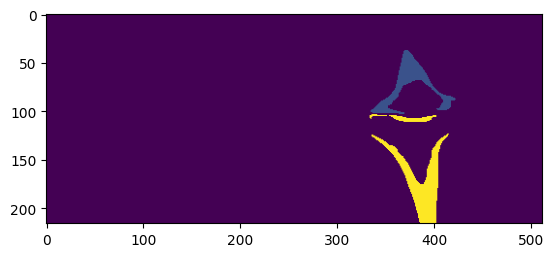

In [34]:
binary_image = sitk.GetImageFromArray(binary)
print(type(binary_image))
labeled = cc_filter.Execute(binary_image)
plt.imshow(sitk.GetArrayFromImage(labeled)[:, coronal_index, :])

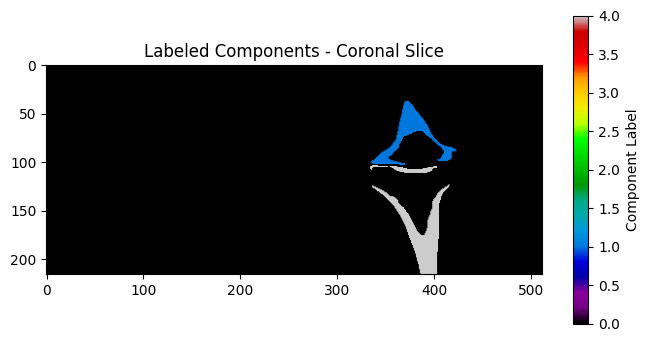

In [45]:
labeled_np = sitk.GetArrayFromImage(labeled) 

# coronal_index = 256  
slice_img = labeled_np[:, coronal_index, :]

plt.figure(figsize=(8, 4))
plt.imshow(slice_img, cmap='nipy_spectral')
plt.title("Labeled Components - Coronal Slice")
plt.colorbar(label='Component Label')
plt.show()

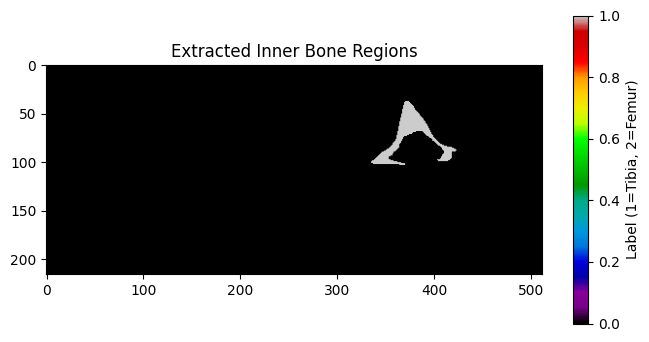

In [ ]:
coronal_slice = labeled_np[:, coronal_index, :]

tibia_label = 1
femur_label = 2

tibia_mask = (coronal_slice == tibia_label).astype(np.uint8)
femur_mask = (coronal_slice == femur_label).astype(np.uint8)

def extract_inner_region(mask):
    outer = clear_border(~mask.astype(bool))
    inner = ~outer & mask.astype(bool)
    return inner.astype(np.uint8)

tibia_inner = extract_inner_region(tibia_mask)
femur_inner = extract_inner_region(femur_mask)

final_mask = np.zeros_like(coronal_slice)
final_mask[tibia_inner == 1] = 1
final_mask[femur_inner == 1] = 2

plt.figure(figsize=(8, 4))
plt.imshow(final_mask, cmap='nipy_spectral')
plt.title("Extracted Inner Bone Regions")
plt.colorbar(label="Label (1=Tibia, 2=Femur)")
plt.show()

### with further techniques step by step

In [ ]:
weak_threshold = 80
strong_threshold = 300
minimum_bone_component_voxels = 4000 # Removes small objects.
slice_shape = image.shape[0]


In [9]:
%%time

print('a')

intensity_clipped_volume = np.clip(image, -1000, 1500)
print('clipped')
vol_min = np.min(intensity_clipped_volume)
vol_max = np.max(intensity_clipped_volume)
normalized_float_volume = ((intensity_clipped_volume - vol_min) / (vol_max - vol_min)).astype(np.float32)
print(f'normalized')
normalized_8bit_volume = (normalized_float_volume * 255).astype(np.uint8)

normalized_float_volume.shape, normalized_8bit_volume.shape

a
clipped
normalized
CPU times: user 408 ms, sys: 325 ms, total: 733 ms
Wall time: 729 ms


((216, 512, 512), (216, 512, 512))

noise reduction filters to each slice


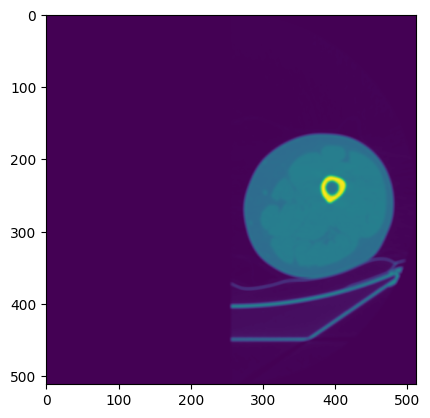

In [10]:
print("noise reduction filters to each slice")
denoised_volume_float = np.zeros_like(normalized_float_volume, dtype=np.float32)
for slice_index in range(slice_shape):
    gaussian_slice = cv.GaussianBlur(normalized_8bit_volume[slice_index, :, :], (5, 5), 3)
    bilateral_slice = cv.bilateralFilter(gaussian_slice, d=9, sigmaColor=75, sigmaSpace=75)
    denoised_volume_float[slice_index, :, :] = bilateral_slice.astype(np.float32) / 255.0

plt.imshow(gaussian_slice)

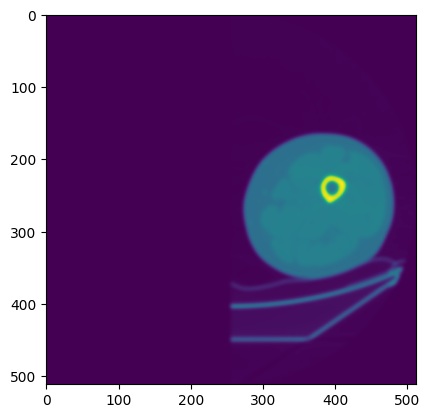

In [11]:
plt.imshow(bilateral_slice)

In [12]:
# Convert to original hounsfield scale
difference = vol_max - vol_min
filtered_hu_volume = (denoised_volume_float * difference) + vol_min
difference

np.int32(2500)

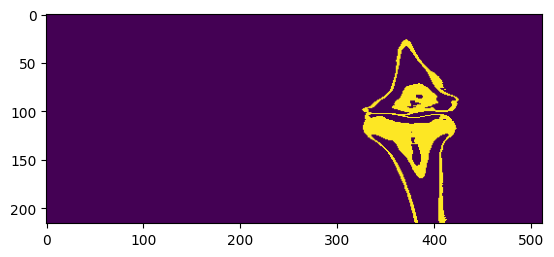

In [14]:
high_confidence_seed_mask = filtered_hu_volume > strong_threshold
potential_bone_region_mask = (filtered_hu_volume > weak_threshold) & (filtered_hu_volume <= strong_threshold)
plt.imshow(potential_bone_region_mask[:, coronal_index, :])

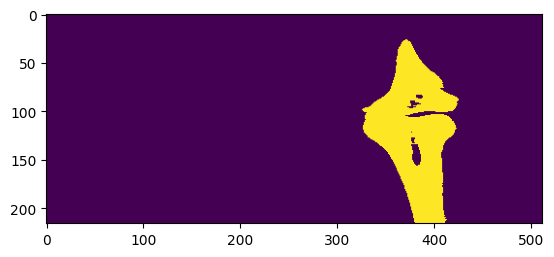

In [18]:
# masking all around the bones, to segment all of it.
connectivity_structure = generate_binary_structure(3, 3)
propagated_segmentation = binary_propagation(high_confidence_seed_mask, mask=potential_bone_region_mask, structure=connectivity_structure)
comprehensive_bone_mask = np.logical_or(high_confidence_seed_mask, propagated_segmentation)
plt.imshow(comprehensive_bone_mask[:, coronal_index, :])

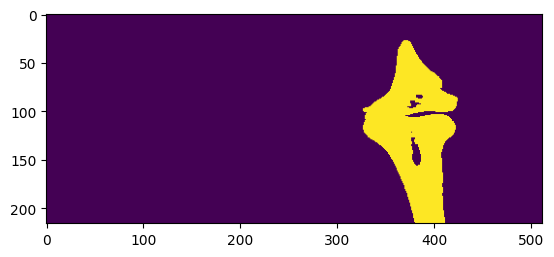

In [19]:
morphologically_opened_mask = binary_opening(comprehensive_bone_mask, structure=np.ones((3, 3, 3)))

labeled_components, num_components = label(morphologically_opened_mask)
component_sizes = nd_sum(morphologically_opened_mask, labeled_components, index=np.arange(num_components + 1))

# removing small objects
final_refined_mask = np.isin(labeled_components, np.where(component_sizes > minimum_bone_component_voxels)[0])
plt.imshow(final_refined_mask[:, coronal_index, :])


In [25]:
def get_largest_object_in_region(region):
    # labels in the region, in the binary mask
    labeled_region, num_objects = label(region)
    if num_objects == 0:
        return np.zeros_like(region, dtype=np.uint8)
    
    object_sizes = nd_sum(region, labeled_region, index=np.arange(1, num_objects + 1))
    largest_object_label = np.argmax(object_sizes) + 1
    
    return (labeled_region == largest_object_label).astype(np.uint8)

In [26]:
vertical_midpoint = final_refined_mask.shape[0] // 2
vertical_midpoint

108

(108, 512, 512)


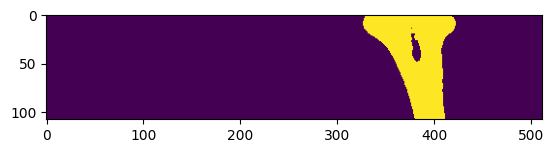

In [33]:
# to store the mask
labeled_output_mask = np.zeros(final_refined_mask.shape, dtype=np.uint8)

# upto the point
upper_half_region = final_refined_mask[:vertical_midpoint, :, :]
femur_component = get_largest_object_in_region(upper_half_region)

# from that point onwards
lower_half_region = final_refined_mask[vertical_midpoint:, :, :]
tibia_component = get_largest_object_in_region(lower_half_region)
print(tibia_component.shape)
plt.imshow(tibia_component[:, coronal_index, :])

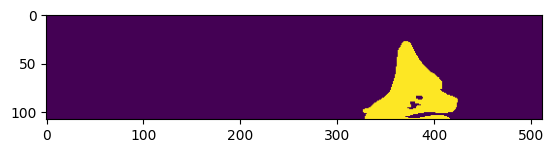

In [34]:
plt.imshow(femur_component[:, coronal_index, :])

### So, lower region and upper region can be separated thus!

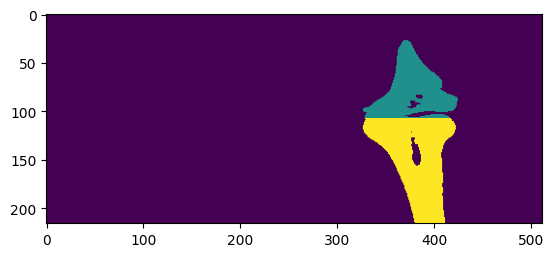

In [35]:
labeled_output_mask[:vertical_midpoint, :, :][femur_component > 0] = 1
labeled_output_mask[vertical_midpoint:, :, :][tibia_component > 0] = 2
plt.imshow(labeled_output_mask[:, coronal_index, :])

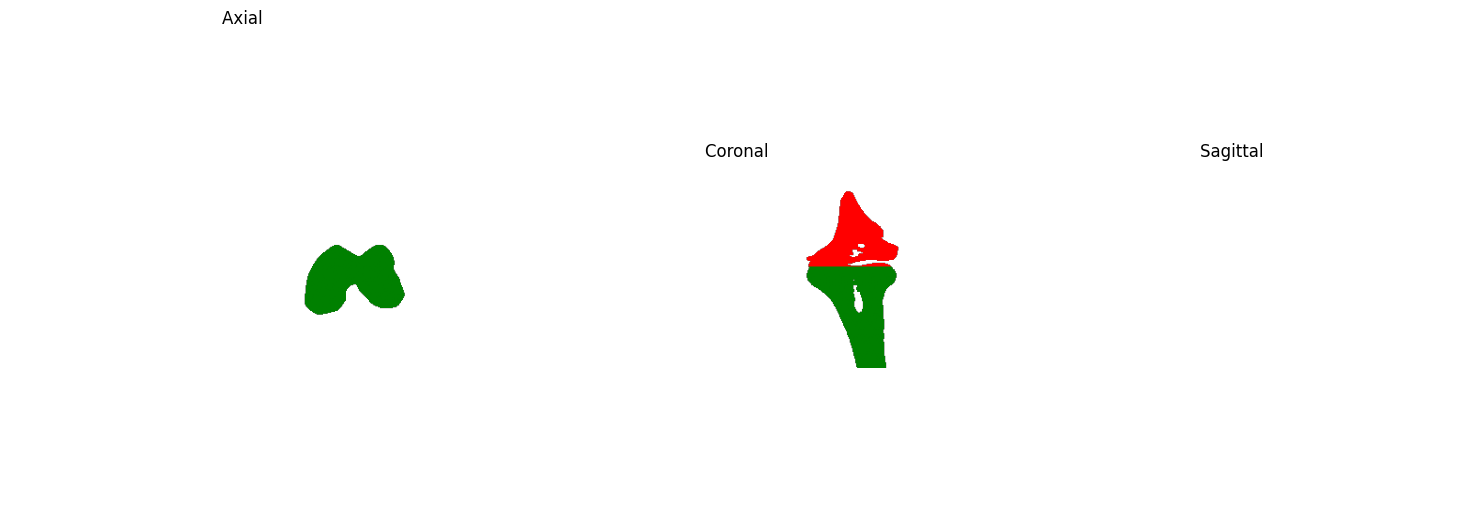

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

custom_cmap = ListedColormap(['none', 'red', 'green'])

axes[0].imshow(labeled_output_mask[axial_index, :, :], cmap=custom_cmap)
axes[0].set_title(f"Axial ")

axes[1].imshow(labeled_output_mask[:, coronal_index, :], cmap=custom_cmap)
axes[1].set_title(f"Coronal ")

axes[2].imshow(labeled_output_mask[:, :, sagittal_index], cmap=custom_cmap)
axes[2].set_title(f"Sagittal ")

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

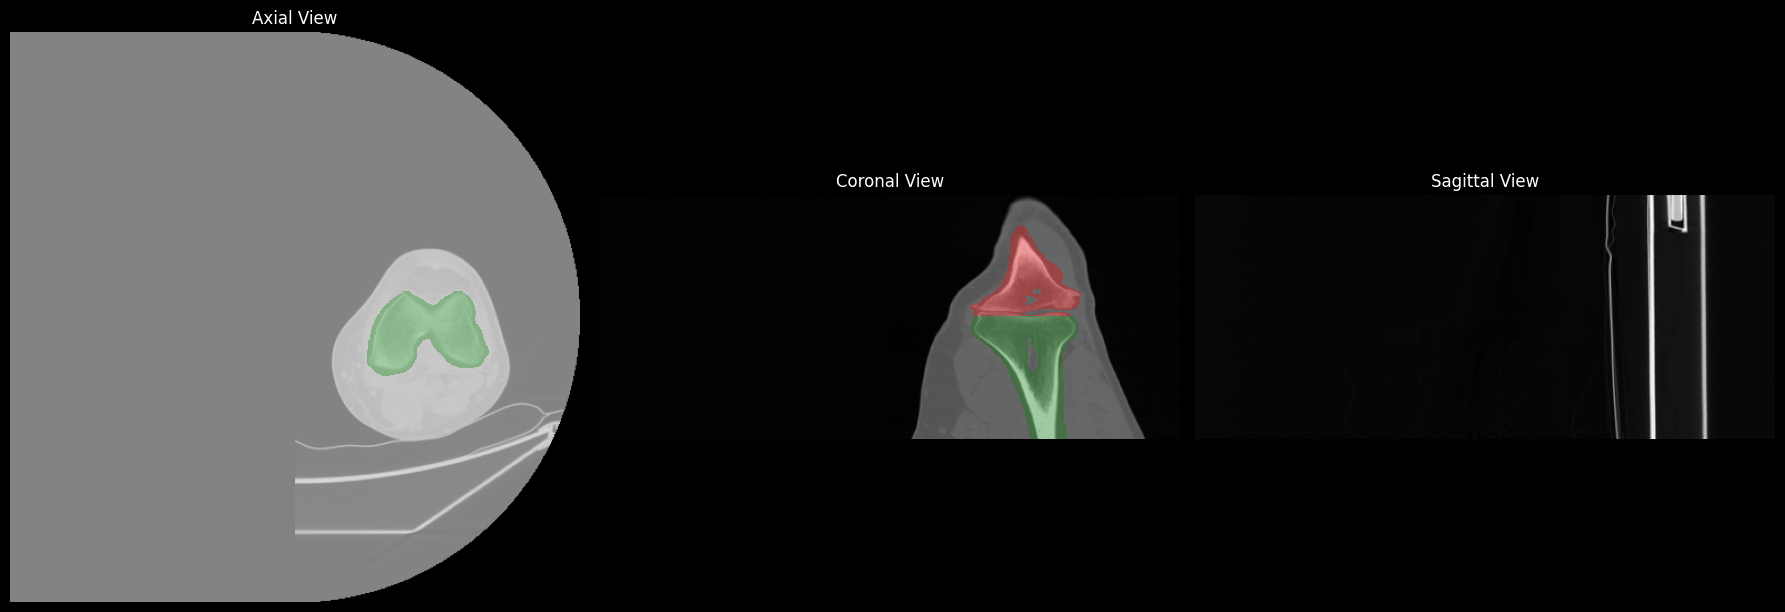

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='black')

# Axial
axes[0].imshow(image[axial_index, :, :], cmap='gray')
axes[0].imshow(labeled_output_mask[axial_index, :, :], cmap=custom_cmap, alpha=0.33, interpolation='none')
axes[0].set_title('Axial View', color='white')

# Coronal
axes[1].imshow(image[:, coronal_index, :], cmap='gray')
axes[1].imshow(labeled_output_mask[:, coronal_index, :], cmap=custom_cmap, alpha=0.33, interpolation='none')
axes[1].set_title('Coronal View', color='white')

# Sagittal
axes[2].imshow(image[:, :, sagittal_index], cmap='gray')
axes[2].imshow(labeled_output_mask[:, :, sagittal_index], cmap=custom_cmap, alpha=0.33, interpolation='none')
axes[2].set_title('Sagittal View', color='white')

for ax in axes:
    ax.axis('off')
    ax.set_facecolor('black')

plt.tight_layout()
plt.show()